In [1]:
import numpy as np 
from PIL import Image
import glob

---
### 전체 사진중 최대 해상도 찾기

In [2]:
# Names
dirNames = ['chair','laptop','piano']

In [3]:
widthRatio = []
heightRatio = []

for name in dirNames:
    for file in sorted(glob.glob(f"../Data/Example/{name}/*.jpg")):
        img = np.array(Image.open(file), dtype=np.int32)
        widthRatio.append(img.shape[1])
        heightRatio.append(img.shape[0])

In [4]:
print("너비 최대 해상도:", np.max(widthRatio))
print("높이 최대 해상도:", np.max(heightRatio))

너비 최대 해상도: 300
높이 최대 해상도: 300


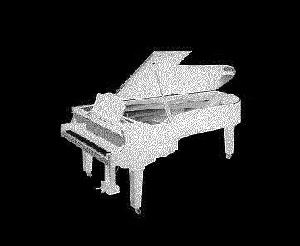

In [ ]:
from PIL import Image, ImageOps

img = Image.open('../Data/Example/piano/image_0001.jpg')
imgGray = img.convert('L')
imgInvert = ImageOps.invert(imgGray)

imgInvert.save('../Data/Example/piano/image_0001.jpg')
# 기존에 있던 파일 지웠어서 나중에 하려면 파일 이름 변경 해야 함
imgInvert


In [ ]:
# 회전, 좌우반전 추가
from PIL import Image
import glob
import os

files = sorted(glob.glob('../Data/Example/laptop/*.jpg'))

savePath = '../Data/Example/Rotate/laptop'
os.makedirs(savePath, exist_ok=True)

counter = len(glob.glob(f'{savePath}/*.jpg'))

for file in files:
    img = Image.open(file)

    for angle in range(15, 16, 1):
        counter += 1
        img2 = img.rotate(angle)
        img2.save(f"{savePath}/image_{counter:04}.jpg")

        counter += 1
        img3 = img2.transpose(Image.FLIP_LEFT_RIGHT)
        img3.save(f"{savePath}/image_{counter:04}.jpg")


In [ ]:
# 전체 사진을 400 * 300 고정 크기로 검은색을 배경으로 맞추기

for name in dirNames:
    fileCount = 0
    for file in sorted(glob.glob(f"../Data/Example/{name}/*.jpg")):
        img = Image.open(file)
        imgResize = img.convert('L') # 이미지를 흑백으로 
        imgArray = np.array(imgResize)

        imgDummy = np.zeros(400*400).reshape(400, 400)
        rowNum = (400 - imgArray.shape[0]) / 2
        colNum = (400 - imgArray.shape[1]) / 2

        # Enpty List에 image array 붙이기
        k = 0
        for i in range(int(rowNum), int(rowNum) + imgArray.shape[0]): 
            l = 0
            for j in range(int(colNum), int(colNum + imgArray.shape[1])):
                imgDummy[i,j] = imgArray[k,l]
                l+=1
            k+=1

        img2 = Image.fromarray(imgDummy.astype('uint8'),'L')
        img2.save(f"../Data/ExampleGray/{name}/image_{fileCount:02}.jpg", "JPEG")
        fileCount+=1

In [ ]:
# Rotate 폴더 이미지도 ExampleGray에 이어서 저장하기

for name in dirNames:
    # ExampleGray에 이미 저장된 파일 개수부터 시작
    fileCount = len(glob.glob(f"../Data/ExampleGray/{name}/image_*.jpg"))

    for file in sorted(glob.glob(f"../Data/Example/Rotate/{name}/*.jpg")):
        img = Image.open(file)
        imgResize = img.convert('L') # 이미지를 흑백으로 
        imgArray = np.array(imgResize)

        imgDummy = np.zeros(400*400).reshape(400, 400)
        rowNum = (400 - imgArray.shape[0]) / 2
        colNum = (400 - imgArray.shape[1]) / 2

        # Empty List에 image array 붙이기
        k = 0
        for i in range(int(rowNum), int(rowNum) + imgArray.shape[0]): 
            l = 0
            for j in range(int(colNum), int(colNum) + imgArray.shape[1]):
                imgDummy[i, j] = imgArray[k, l]
                l += 1
            k += 1

        img2 = Image.fromarray(imgDummy.astype('uint8'), 'L')
        img2.save(f"../Data/ExampleGray/{name}/image_{fileCount:02}.jpg", "JPEG")
        fileCount += 1


#### 사진들을 numpy배열을 이용하여 Training Data 만들기

In [5]:
number_of_data = 39 * len(dirNames)
img_width_size = 400
img_height_size = 400

In [6]:
train = np.zeros(
        number_of_data * img_width_size * img_height_size,
        dtype=np.int32
).reshape(number_of_data, img_height_size, img_width_size ) # row,(높이면 로우) col

In [7]:
i = 0
for name in dirNames:
    for file in sorted(glob.glob(f'../Data/ExampleGray/{name}/*.jpg')):
        img = np.array(Image.open(file),dtype=np.int32)
        train[i,:,:] = img
        i += 1
    

In [8]:
train.shape

(117, 400, 400)

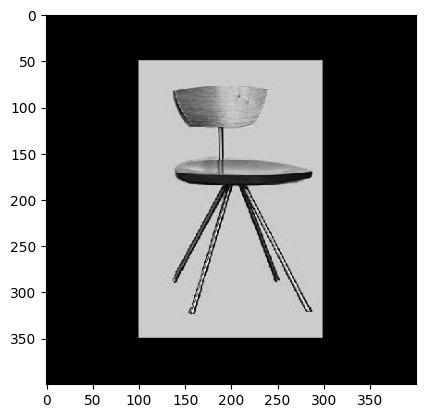

In [9]:
# 이미지 확인하기
import matplotlib.pyplot as plt
plt.imshow(train[0].reshape(400, 400), cmap='gray')
plt.show()

In [10]:
dirNames

['chair', 'laptop', 'piano']

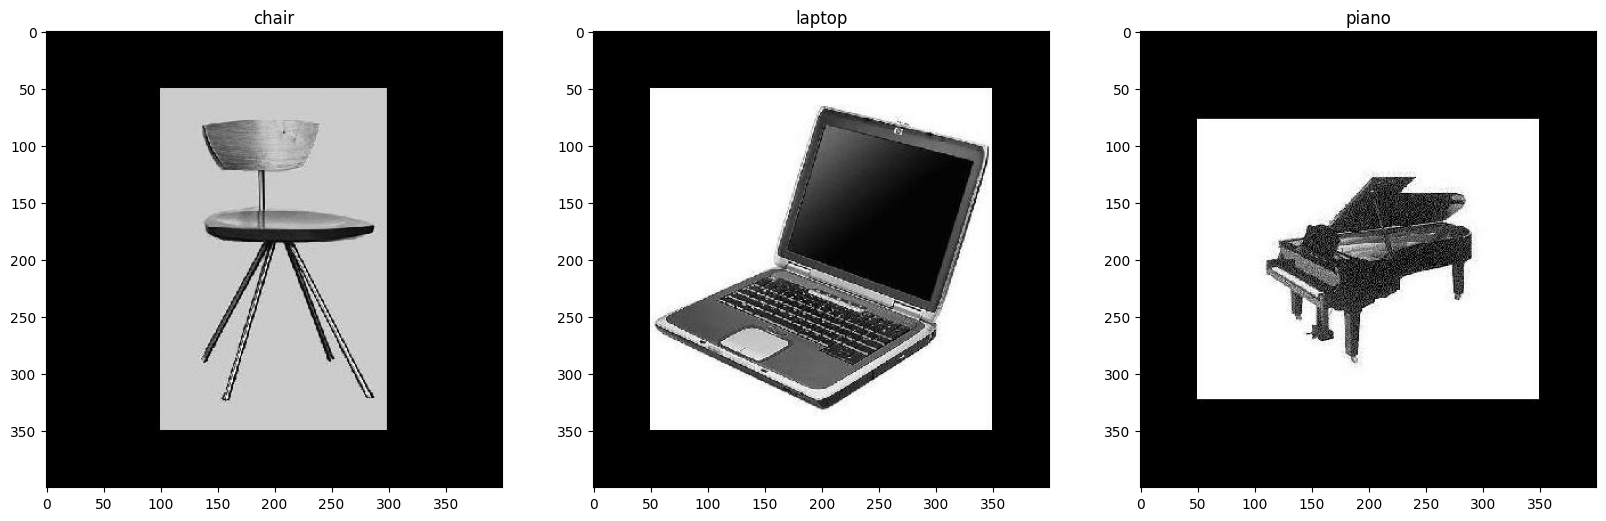

In [11]:
plt.figure(figsize=(20,20))
orderNo = range(0,len(dirNames)*39,39)


for i in range(1,len(dirNames)+1):
    plt.subplot(1,len(dirNames), i)
    plt.imshow(train[orderNo[i-1]].reshape(400,400),cmap='gray')
    plt.title(dirNames[i-1])

In [12]:
# Target
target = np.concatenate(
    [   
    np.zeros(39),np.ones(39),np.full(39,2)
    ]
)

In [13]:
len(target)

117

In [14]:
target

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.])

In [15]:
train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [16]:
train_scaled = train.reshape(-1, 400, 400, 1) / 255

In [17]:
import pandas as pd
import warnings 
import koreanize_matplotlib
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow import keras
warnings.filterwarnings('ignore')

In [18]:
train_data, valid_data, train_target, valid_target = train_test_split(
    train_scaled, 
    target,
    test_size=0.2,
    random_state=42
) 

In [19]:
model = keras.Sequential()

model.add(keras.layers.Conv2D(
    32,
    kernel_size=3,
    activation='relu',
    padding='same',
    input_shape = (400,400,1)
))
model.add(keras.layers.MaxPool2D(2))

In [20]:


model.add(keras.layers.Conv2D(
    64,
    kernel_size=3,
    activation='relu',
    padding='same',
))
model.add(keras.layers.MaxPool2D(2))

In [21]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(100, activation='relu'))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(3, activation='softmax'))

In [22]:
model.summary() # 결과값이 ? 로 나오는데 확인 필요/ 일전에는 안그랬던 거 같아서 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 400, 400, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 200, 200, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 200, 200, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │    64,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,019,219 (244.21 MB)

 Trainable params: 64,019,219 (244.21 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    loss = 'sparse_categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy'],
)
checkpoint_cb = keras.callbacks.ModelCheckpoint('../Data/best_model.keras')
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

history = model.fit(
    train_scaled, 
    np.array(target), 
    epochs=20, 
    validation_data=(valid_data, np.array(valid_target)),
    callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.3761 - loss: 9.8525 - val_accuracy: 0.8333 - val_loss: 0.8340
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.6752 - loss: 1.7780 - val_accuracy: 0.8333 - val_loss: 0.5808
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.7179 - loss: 0.7422 - val_accuracy: 0.9583 - val_loss: 0.5088
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.8718 - loss: 0.5239 - val_accuracy: 0.9583 - val_loss: 0.2585
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.9231 - loss: 0.2649 - val_accuracy: 0.8750 - val_loss: 0.1848
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 4s/step - accuracy: 0.9316 - loss: 0.1525 - val_accuracy: 1.0000 - val_loss: 0.0344
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.9915 - loss: 0.0548 - val_accuracy: 1.0000 - val_loss: 0.0413
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 1.0000 - loss: 0.0334 - val_accuracy: 1.0000 - val_loss: 0.0282
Epoch 9/

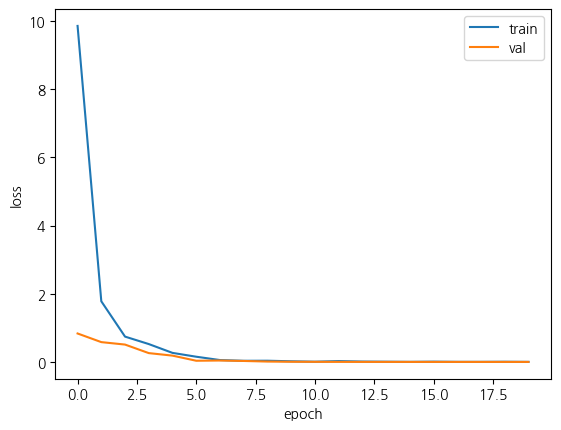

In [24]:
# 시각화 
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

In [27]:

for i in range(len(train_scaled)):
    pred = model.predict(train_scaled[i:i+1])
    print('index : ',i, dirNames[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
index :  0 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
index :  1 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
index :  2 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
index :  3 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
index :  4 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
index :  5 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
index :  6 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
index :  7 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
index :  8 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
index :  9 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
index :  10 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
index :  11 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
index :  12 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
index :  13 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
index :  14 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
index :  15 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
index :  16 chair
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
index :  17 chair
1/